In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
data = pd.read_csv("insurance.csv")

print(data.head())


   age     sex   bmi  children smoker     region  expenses
0   19  female  27.9         0    yes  southwest  16884.92
1   18    male  33.8         1     no  southeast   1725.55
2   28    male  33.0         3     no  southeast   4449.46
3   33    male  22.7         0     no  northwest  21984.47
4   32    male  28.9         0     no  northwest   3866.86


In [ ]:
print(data.shape)
print(data.info())
print(data.describe())


(1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
               age          bmi     children      expenses
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.665471     1.094918  13270.422414
std      14.049960     6.098382     1.205493  12110.011240
min      18.000000    16.000000     0.000000   1121.870000
25%      27.000000    26.300000     0.000000   4740.287500
50%      39.000000    30.400000     1.000000   9382.030000
75%      51.000000    34.700000     2.000000  16639.

In [ ]:
print(data.isnull().sum())


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64


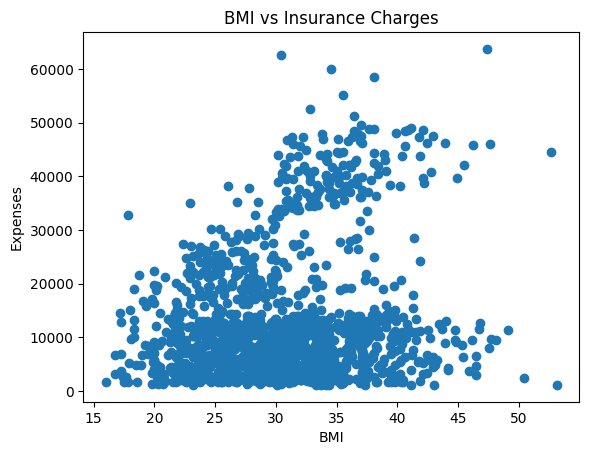

In [ ]:
plt.scatter(data['bmi'], data['expenses'])
plt.xlabel("BMI")
plt.ylabel("Expenses")
plt.title("BMI vs Insurance Charges")
plt.show()

In [ ]:
data = pd.get_dummies(data, drop_first=True)

print(data.head())


   age   bmi  children  expenses  sex_male  smoker_yes  region_northwest  \
0   19  27.9         0  16884.92     False        True             False   
1   18  33.8         1   1725.55      True       False             False   
2   28  33.0         3   4449.46      True       False             False   
3   33  22.7         0  21984.47      True       False              True   
4   32  28.9         0   3866.86      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


In [ ]:
X = data.drop('expenses', axis=1)

In [ ]:
y = data['expenses']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.linear_model import LinearRegression


In [ ]:
lr = LinearRegression()


In [ ]:
lr.fit(X_train, y_train)


LinearRegression()

In [ ]:
y_pred = lr.predict(X_test)


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)


Mean Squared Error: 33600065.355077825
R2 Score: 0.7835726930039906


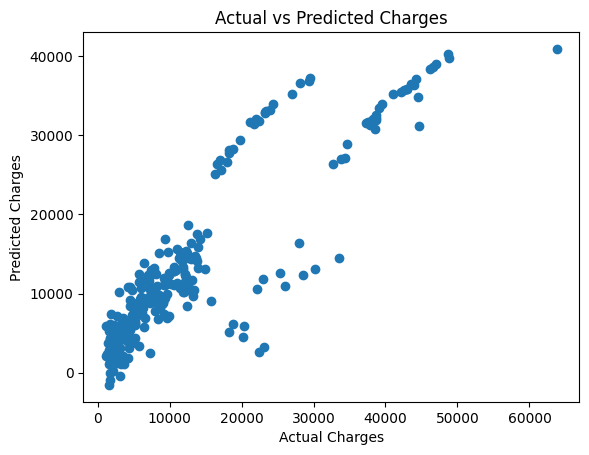

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")
plt.show()


In [ ]:
median = data['expenses'].median()

data['premium_category'] = (data['expenses'] > median).astype(int)

In [ ]:
X = data.drop(['expenses', 'premium_category'], axis=1)
y = data['premium_category']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.linear_model import LogisticRegression


In [ ]:
logr = LogisticRegression(max_iter=1000)
logr.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = logr.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.9104477611940298


In [ ]:
print(confusion_matrix(y_test, y_pred))


[[131  15]
 [  9 113]]
